In [1]:
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import numba as nb
import re

In [2]:
from cosmo_numba.B_modes.cosebis import COSEBIS

In [ ]:
import matplotlib as mpl

mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

mpl.rcParams['font.size'] = 13

mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5
mpl.rcParams['xtick.major.size'] = 7
mpl.rcParams['ytick.major.size'] = 7


mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [4]:
SAVE_FIGS = False

## Cosmo model

In [5]:
def get_model(
    theta,
    z,
    nz,
    Omega_c,
    h,
    Omega_b,
    sig8,
    ns,
    B_amp,
    b_ia,
    l_min=None,
    l_max=None,
    ell=None,
):

    theta_deg = theta/60

    cosmo = ccl.Cosmology(
        Omega_c=Omega_c,
        Omega_b=Omega_b,
        h=h,
        n_s=ns,
        sigma8=sig8,

        transfer_function='boltzmann_camb',
        matter_power_spectrum='camb',
        extra_parameters={
            "camb": {
                "halofit_version": 'mead2016',
                "HMCode_A_baryon": B_amp,
                "kmax": 21,
                # We do this to avoid warnings in CAMB with (kmax < 5 or
                # 'kmax < 20 and z > 4') (set internally in ccl)
                # default: kmax=10
            }
        }
    )
    ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = True

    lens = ccl.WeakLensingTracer(
        cosmo,
        dndz=(z, nz),
        ia_bias=(z, np.ones_like(z)*b_ia),
        use_A_ia=True,
    )

    if ell is None:
        if l_min is None and l_max is None:
            l_min = 1
            l_max = 100_000
        l_bin = (l_max - l_min) + 1
        ell = np.logspace(np.log10(l_min), np.log10(l_max), l_bin)
    cl = ccl.angular_cl(cosmo, lens, lens, ell)

    xip_fit = ccl.correlation(
        cosmo,
        ell=ell,
        C_ell=cl,
        theta=theta_deg,
        type='GG+',
        method='fftlog',
    )
    xim_fit = ccl.correlation(
        cosmo,
        ell=ell,
        C_ell=cl,
        theta=theta_deg,
        type='GG-',
        method='fftlog'
    )

    return xip_fit, xim_fit, ell, cl

In [6]:
def smail_nz(z, z0, alpha, beta):
    return (z / z0) ** beta * np.exp(-(z / z0) ** alpha)

## Set parameters

In [7]:
tmin = 0.5
tmax = 250.

nbins = 10_000

In [8]:
# Planck cosmo 2018 | TT,TE,EE+lowE+lensing+BAO
h = 0.6766
Om = 0.3111
Ov = 0.6889
sig8 = 0.8102
ns = 0.9665
Ob_h2 = 0.02242
Ob = Ob_h2/h**2
Oc_h2 = 0.11933
Oc = Oc_h2/h**2
b_ia = 0.5
B_amp = 3.13

area = 14_300
shape_noise = 0.26
n_eff = 27

alpha_nz = 0.68
beta_nz = 2.
z0_nz = 0.13
z = np.linspace(0, 4, 256)
nz = smail_nz(z, z0_nz, alpha_nz, beta_nz)

## Get $\xi_{\pm}$ model

In [9]:
theta_ = np.logspace(np.log10(tmin), np.log10(tmax), nbins+1)
theta = np.mean([theta_[:-1], theta_[1:]], axis=0)
dtheta = np.diff(theta_)

In [10]:
xip_model, xim_model, ell, Cell = get_model(
    theta,
    z,
    nz,
    Oc,
    h,
    Ob,
    sig8,
    ns,
    B_amp,
    b_ia,
)

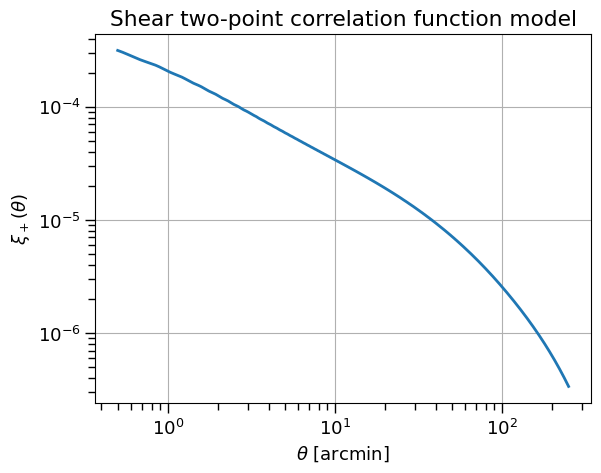

In [11]:
plt.plot(theta , xip_model)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$\xi_+(\theta)$")
plt.title("Shear two-point correlation function model")
plt.grid()
plt.show()

## Compute roots and norms

In [12]:
N_mode = 20

In [13]:
cosebis = COSEBIS(theta_min=tmin, theta_max=tmax, N_max=N_mode)

In [14]:
cosebis.compute_roots()

In [15]:
C_E, C_B = cosebis.cosebis_from_xipm(theta, xip_model, xim_model, parallel=False)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


#### Read Mathematica roots and norms

In [16]:
with open("../tests/cosmo_numba/data/cosebi_tplog_rN_20_0.500_250.000.dat") as f:
    lines = f.readlines()

roots_mm = []
for i in range(3, N_mode + 3):
    r_str = re.split("\t", lines[i].strip())

    roots_mm.append(
        np.array([np.float64(rr) for rr in r_str])
    )
roots_mm = nb.typed.List(
            [
                np.array([np.float64(roots_tmp) for roots_tmp in roots_n_tmp])
                for roots_n_tmp in roots_mm
            ]
        )

norms_mm = []
for i in range(N_mode + 3, 2 * N_mode + 3):
    n_str = lines[i].strip()

    norms_mm.append(np.float64(lines[i].strip()))
norms_mm = np.array(norms_mm)

In [17]:
Tp_log_mm = cosebis.get_Tp_log(theta, roots=roots_mm, norms=norms_mm)
Tm_log_mm = cosebis.get_Tm_log(theta, roots=roots_mm, norms=norms_mm)

In [18]:
precisions = [15, 30, 50, 80]
Tp_logs = []
Tm_logs = []
C_Es = []
C_Bs = []
for prec in tqdm(precisions):
    cosebis_ = COSEBIS(theta_min=tmin, theta_max=tmax, N_max=N_mode, precision=prec)
    Tp_log_ = cosebis_.get_Tp_log(theta)
    Tm_log_ = cosebis_.get_Tm_log(theta)
    C_E, C_B = cosebis_.cosebis_from_xipm(theta, xip_model, xim_model, parallel=True)
    Tp_logs.append(Tp_log_)
    Tm_logs.append(Tm_log_)
    C_Es.append(C_E)
    C_Bs.append(C_B)
    del cosebis_

100%|██████████| 4/4 [00:19<00:00,  4.94s/it]


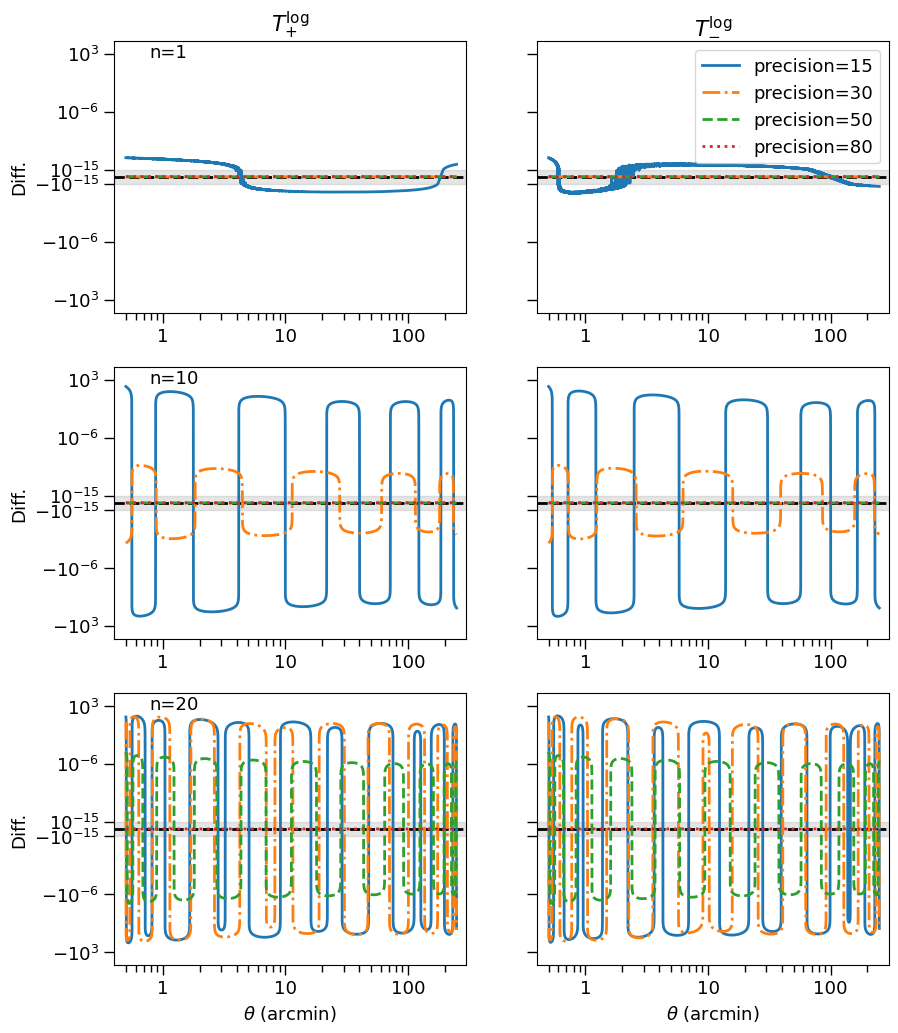

In [19]:
modes = [0, 9, 19]
markers = ["-", "-.", "--", ":"]
fig, axes = plt.subplots(
    3, 2,
    figsize=(10, 12),
    sharey=True,
    gridspec_kw={
        'height_ratios': [1, 1, 1],
    },
)
for i, mode in enumerate(modes):
    axes[i, 0].axhline(0, ls='--', color='k')
    axes[i, 1].axhline(0, ls='--', color='k')
    axes[i, 0].text(0.1, 0.94, f"n={mode+1}", transform=axes[i, 0].transAxes)
    for j, prec in enumerate(precisions):
        axes[i, 0].plot(theta, (Tp_logs[j][mode] - Tp_log_mm[mode]), label="precision="+str(prec), linestyle=markers[j])
        axes[i, 1].plot(theta, (Tm_logs[j][mode] - Tm_log_mm[mode]), label="precision="+str(prec), linestyle=markers[j])

    # keep log spacing visually but allow plotting 0 using symlog
    linthresh = 1e-15  # linear region half-width around 0 (data units)
    linscale = 1.0    # visual size of linear region relative to log region
    axes[i, 0].set_yscale('symlog', linthresh=linthresh, linscale=linscale, base=10)
    # Highlight linear region
    x0 = theta.min()*0.8
    x1 = theta.max()*1.2
    axes[i, 0].fill_between([x0, x1], -linthresh, linthresh, color='gray', alpha=0.2, zorder=0)
    axes[i, 1].fill_between([x0, x1], -linthresh, linthresh, color='gray', alpha=0.2, zorder=0)
    axes[i, 0].set_xlim(x0, x1)
    axes[i, 1].set_xlim(x0, x1)

    # Set y-limits to see written mode better
    axes[i, 0].set_ylim(-1e5, 1e5)

    # powers = np.arange(-16, 3, 8)  # exponents from 1e-17 up to 1e3, step controls density
    powers = np.round(np.linspace(-15, 3, 3, endpoint=True))
    major_ticks = np.concatenate((-10.0 ** powers, 10.0 ** powers))
    # Apply ticks and a compact formatter
    axes[i, 0].set_yticks(np.unique(major_ticks))

    axes[i, 0].yaxis.set_tick_params(which='minor', left=False)
    axes[i, 1].yaxis.set_tick_params(which='minor', left=False)

    axes[i, 0].set_ylabel(r"Diff.")

    for j in range(2):
        axes[i, j].set_xscale("log")
        axes[i, j].set_xticks([1, 10, 100])
        axes[i, j].set_xticklabels([1, 10, 100])
        # axes[i, j].set_xlabel(r"$\theta$ (arcmin)")
axes[2, 0].set_xlabel(r"$\theta$ (arcmin)")
axes[2, 1].set_xlabel(r"$\theta$ (arcmin)")
axes[0, 1].legend()
axes[0, 0].set_title(r"$T_{+}^{\rm{log}}$")
axes[0, 1].set_title(r"$T_{-}^{\rm{log}}$")
if SAVE_FIGS:
    plt.savefig("../paper/cosebis_prec_Tpm.png")
plt.show()

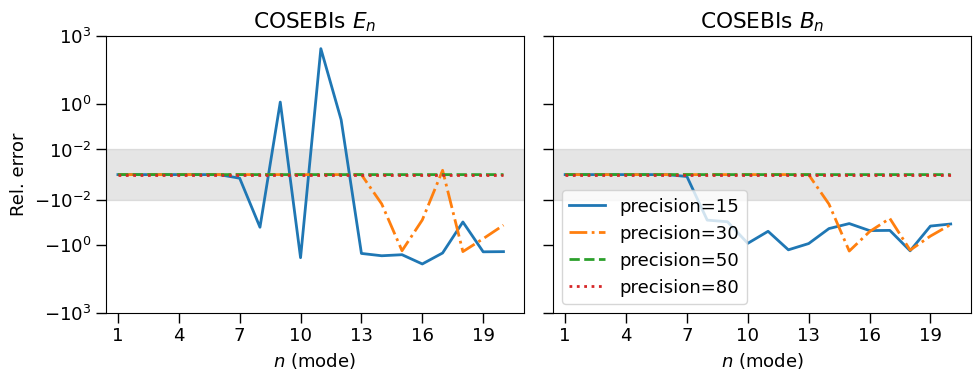

In [20]:
start_mode = 1
plot_modes = range(start_mode, 21)
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
for i, prec in enumerate(precisions):
    axes[0].plot(plot_modes, (C_Es[i][start_mode-1:]-C_Es[-1][start_mode-1:])/C_Es[-1][start_mode-1:], label="precision="+str(prec), color=color[i], linestyle=markers[i])
    axes[1].plot(plot_modes, (C_Bs[i][start_mode-1:]-C_Bs[-1][start_mode-1:])/C_Bs[-1][start_mode-1:], label="precision="+str(prec), color=color[i], linestyle=markers[i])

linthresh = 1e-2  # linear region half-width around 0 (data units)
linscale = 1.0    # visual size of linear region relative to log region
axes[0].set_yscale('symlog', linthresh=linthresh, linscale=linscale, base=10)
x0 = 0.4
x1 = 21
axes[0].fill_between([x0, x1], -linthresh, linthresh, color='gray', alpha=0.2, zorder=0)
axes[1].fill_between([x0, x1], -linthresh, linthresh, color='gray', alpha=0.2, zorder=0)
axes[0].set_xlim(x0, x1)
axes[1].set_xlim(x0, x1)


# Use SymmetricalLogLocator for symlog behavior but choose a small, explicit
# set of major ticks so the axis is not crowded (powers-of-ten every 3 decades).
powers = np.round(np.linspace(-2, 3, 3, endpoint=True))
major_ticks = np.concatenate((-10.0 ** powers, 10.0 ** powers))
# Apply ticks and a compact formatter
axes[0].set_yticks(np.unique(major_ticks))
axes[0].yaxis.set_tick_params(which='minor', left=False)
axes[1].yaxis.set_tick_params(which='minor', left=False)
axes[0].set_ylabel(r"Rel. error")

for i in range(2):
    xticks = np.arange(1, 20, 3, dtype=int,)
    axes[i].set_xticks(xticks)
    axes[i].set_xlabel(r"$n$ (mode)")
axes[0].set_title(r"COSEBIs $E_{n}$")
axes[1].set_title(r"COSEBIs $B_{n}$")
axes[1].legend(loc="lower left")
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("../paper/cosebis_prec_EB.png")

## Compare COSEBIs computation

In [21]:
cosebis = COSEBIS(theta_min=theta[0], theta_max=theta[-1], N_max=N_mode)
cosebis.compute_roots()

In [22]:
C_E, C_B = cosebis.cosebis_from_xipm(theta, xip_model, xim_model)

In [23]:
C_E_l, C_B_l = cosebis.cosebis_from_Cell(ell, Cell, np.zeros_like(Cell))

## Covariance

### Cov analytic

In [24]:
cov_pm = np.load("../tests/cosmo_numba/data/cosmocov_cov_lsst_xipm_0.5_250_1000.npy")

In [25]:
theta_cov_ = np.logspace(np.log10(tmin), np.log10(tmax), 1_000+1)
theta_cov = np.mean([theta_cov_[:-1], theta_cov_[1:]], axis=0)

In [26]:
cov_EB = cosebis.cosebis_covariance_from_xipm_covariance(theta_cov, cov_pm)

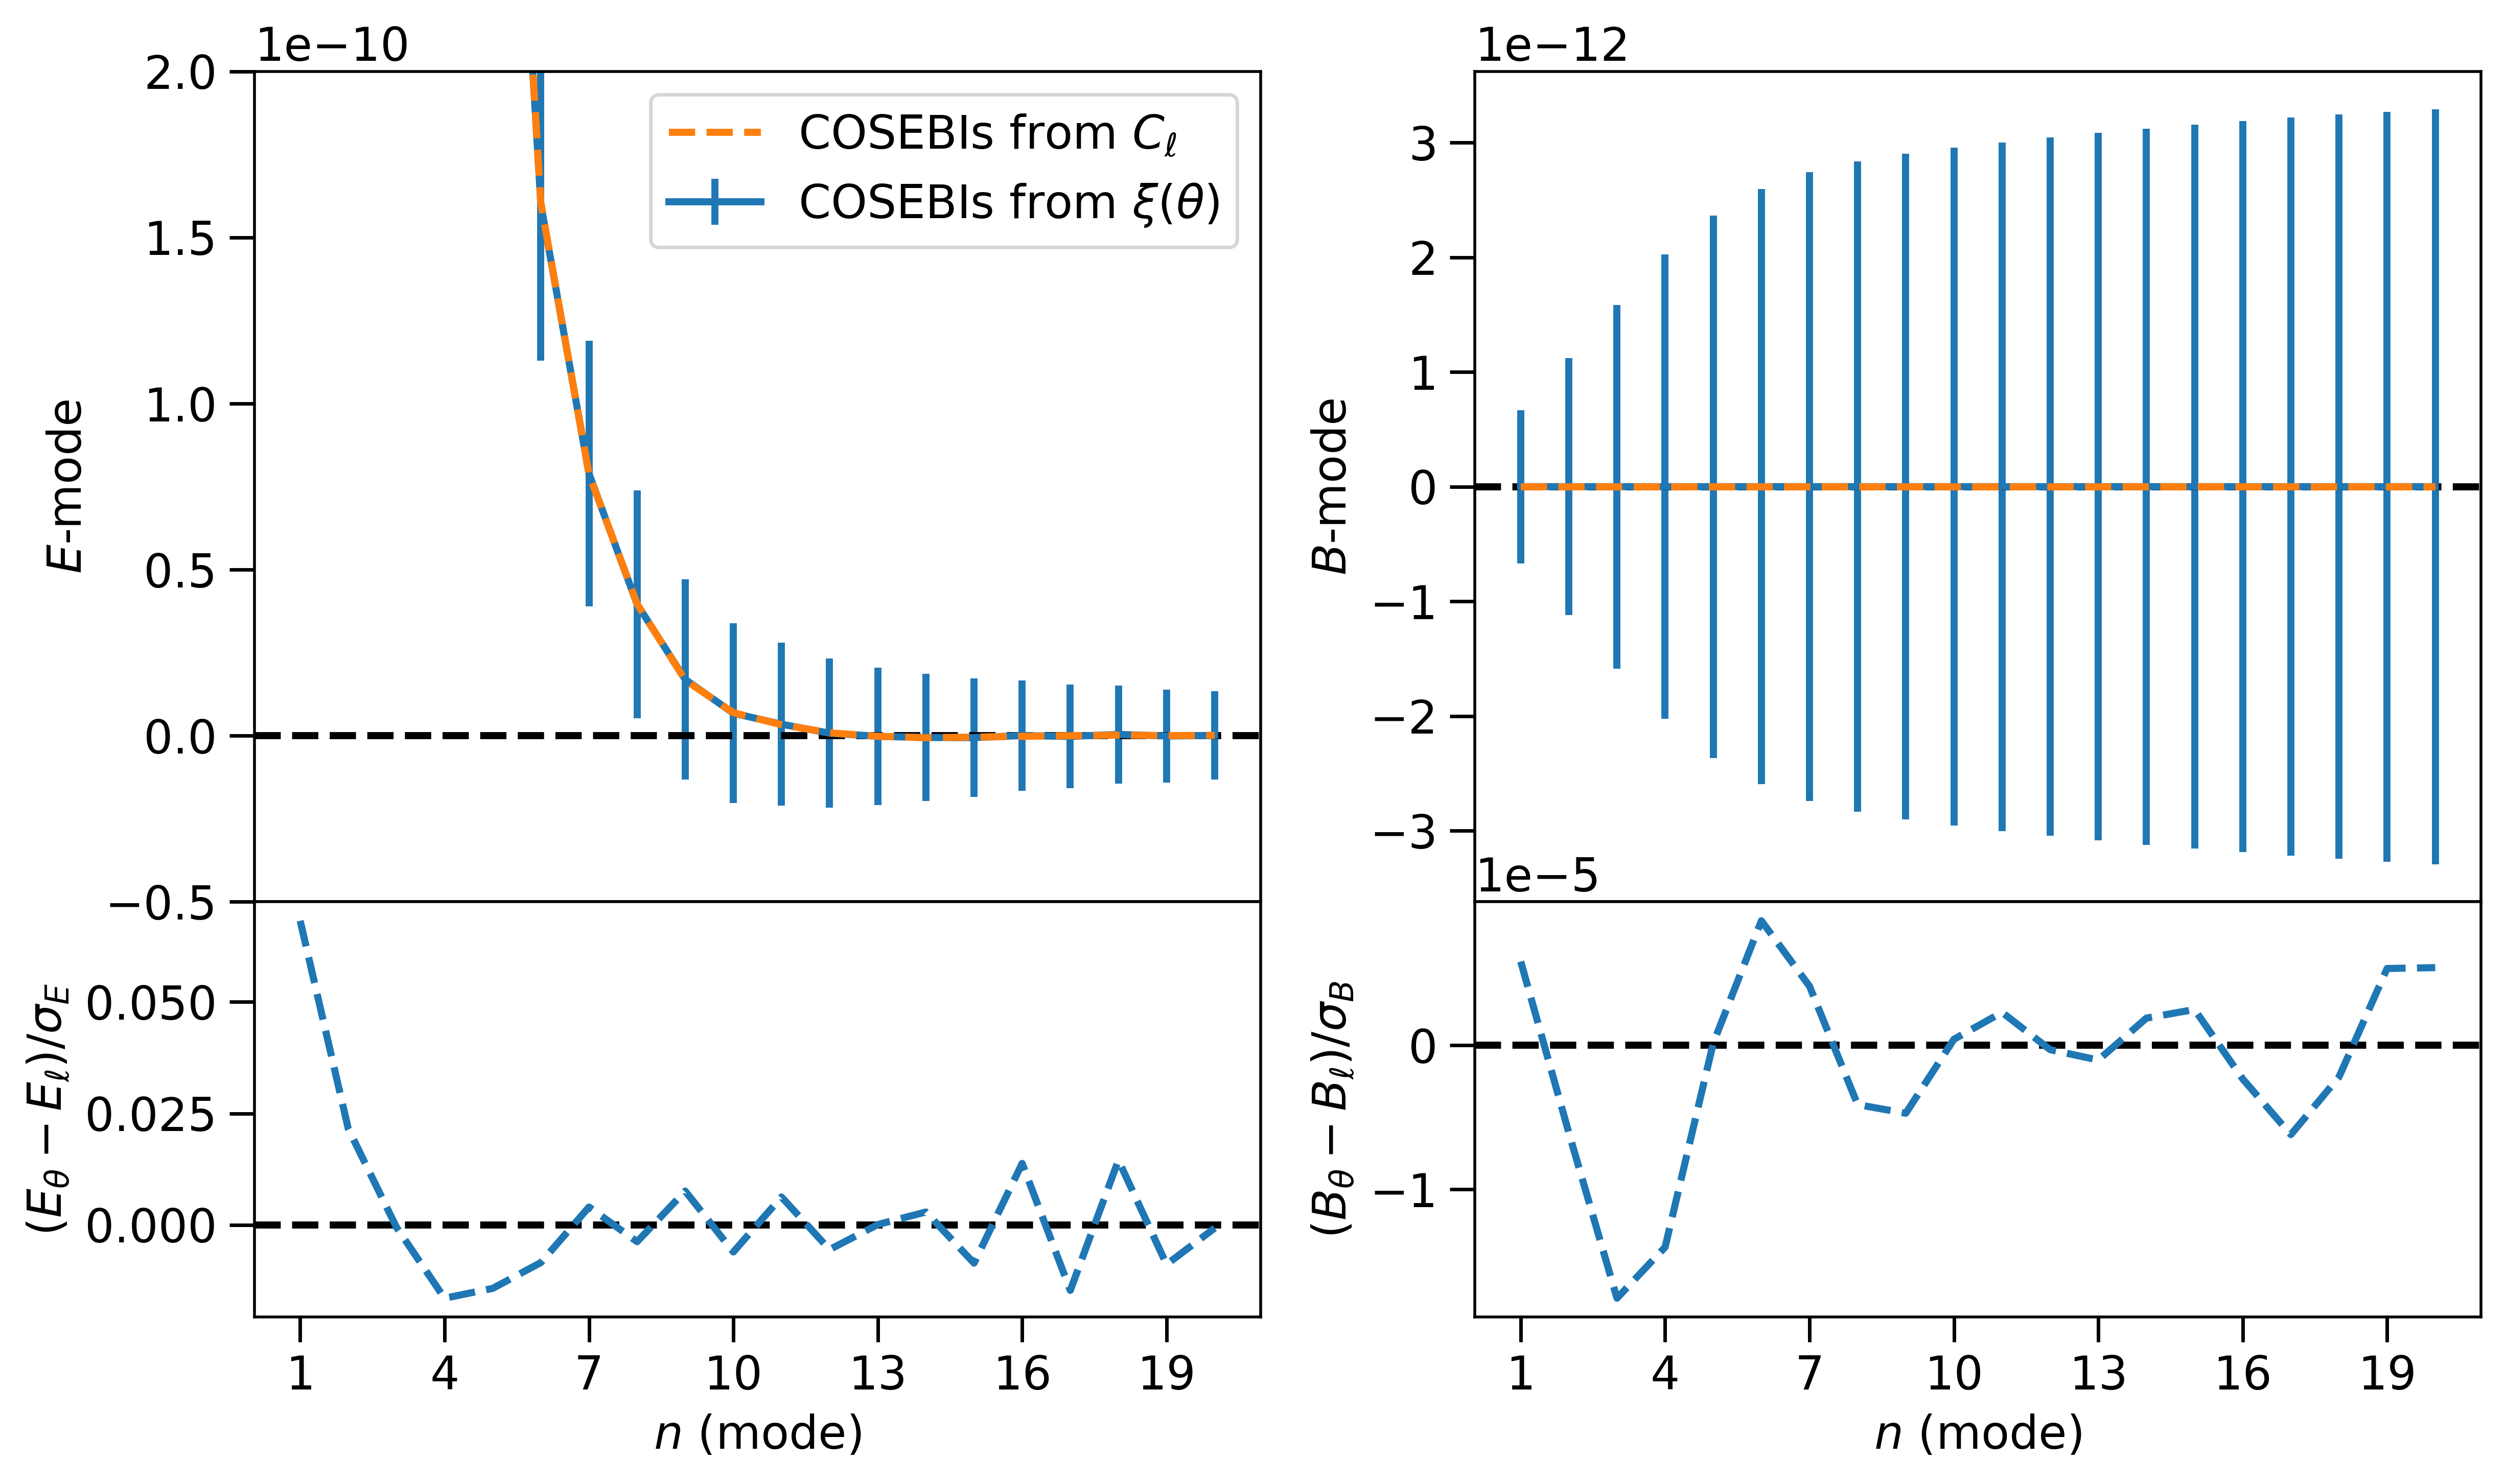

In [27]:
fig, axes = plt.subplots(
    2, 2,
    sharex=True,
    gridspec_kw={
        "hspace": 0.0,
        'height_ratios': [0.4, 0.2, ],
    },
    figsize=(10, 6), dpi=500
)
axes[0, 0].errorbar(range(1, 21), C_E, yerr=np.sqrt(np.diag(cov_EB[:20, :20])), label=r"COSEBIs from $\xi(\theta)$")
axes[0, 0].plot(range(1, 21), C_E_l, "--", label=r"COSEBIs from $C_{\ell}$", zorder=10)
axes[0, 0].axhline(0, ls='--', color="k")
axes[0, 0].legend()
axes[0, 0].set_xticks(range(1, 21)[::3])
axes[0, 0].legend()
axes[0, 0].set_ylim(-0.5e-10, 2e-10)
axes[0, 0].set_xlabel(r"$n$ (mode)")
axes[0, 0].set_ylabel(r"$E$-mode")

axes[0, 1].errorbar(range(1, 21), C_B, yerr=np.sqrt(np.diag(cov_EB[20:, 20:])), label=r"COSEBIs from $\xi(\theta)$")
axes[0, 1].plot(range(1, 21), C_B_l, "--", label=r"COSEBIs from $C_{\ell}$", zorder=10)
axes[0, 1].axhline(0, ls='--', color="k")
# axes[0, 1].legend()
# axes[0, 1].set_ylim(-1e-14, 1e-14)
axes[0, 1].set_xticks(range(1, 21)[::3])
axes[0, 1].set_xlabel(r"$n$ (mode)")
axes[0, 1].set_ylabel(r"$B$-mode")


axes[1, 0].plot(range(1, 21), (C_E - C_E_l)/np.sqrt(np.diag(cov_EB[:20, :20])), "--", label=r"COSEBIs from $C_{\ell}$", zorder=10)
axes[1, 0].axhline(0, ls='--', color="k")
axes[1, 0].set_xticks(range(1, 21)[::3])
# axes[1, 0].legend()
# axes[1, 0].set_ylim(-0.5e-10, 8.5e-10)
axes[1, 0].set_xlabel(r"$n$ (mode)")
axes[1, 0].set_ylabel(r"$(E_{\theta} - E_{\ell})/\sigma_{E}$")

axes[1, 1].plot(range(1, 21), (C_B - C_B_l)/np.sqrt(np.diag(cov_EB[20:, 20:])), "--", label=r"COSEBIs from $C_{\ell}$", zorder=10)
axes[1, 1].axhline(0, ls='--', color="k")
# axes[1, 1].legend()
# axes[1, 1].set_ylim(-1e-14, 1e-14)
axes[1, 1].set_xticks(range(1, 21)[::3])
axes[1, 1].set_xlabel(r"$n$ (mode)")
axes[1, 1].set_ylabel(r"$(B_{\theta} - B_{\ell})/\sigma_{B}$")
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("../paper/cosebis_EB_xi_Cl.png")